# Correlation-Weighted Bimodal GAT for S&P500 Asset Price Forecasting

This notebook:
1) Downloads OHLCV data via **yfinance** and builds **dynamic correlation graphs** (top-k edges).
2) Builds **text embeddings** (FinBERT) — disabled by default to keep the run light.
3) Runs a **simple training loop** using PyTorch Geometric.


In [1]:
# If you're running this in a fresh environment, uncomment:
# !pip install -r requirements.txt

import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve() # change if needed
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /Users/parinpatel/Desktop/stock_corr_gat_project


## 1) Configure the experiment

In [2]:
# ----------------------------
# Data + experiment parameters
# ----------------------------
# ~100 large-cap S&P 500 tickers, split across sectors (GICS-style buckets)
SECTOR_TICKERS = {
    "Information Technology": [
        "AAPL","MSFT","NVDA","AVGO","ORCL","ADBE","CRM","CSCO","INTU","AMD"
    ],
    "Health Care": [
        "UNH","JNJ","LLY","ABBV","MRK","PFE","TMO","ABT","DHR"
    ],
    "Financials": [
        "JPM","BAC","WFC","GS","MS","C","SCHW","BLK","AXP"
    ],
    "Consumer Discretionary": [
        "AMZN","TSLA","HD","MCD","NKE","LOW","SBUX","BKNG","TGT"
    ],
    "Communication Services": [
        "GOOGL","GOOG","META","NFLX","DIS","TMUS","T","VZ","CMCSA"
    ],
    "Industrials": [
        "HON","UPS","BA","CAT","DE","GE","LMT","RTX","UNP"
    ],
    "Consumer Staples": [
        "PG","KO","PEP","COST","WMT","PM","MO","MDLZ","CL"
    ],
    "Energy": [
        "XOM","CVX","COP","EOG","SLB","MPC","VLO","PSX","OXY"
    ],
    "Utilities": [
        "NEE","DUK","SO","AEP","EXC","SRE","D","XEL","ED"
    ],
    "Real Estate": [
        "AMT","PLD","CCI","EQIX","SPG","O","PSA","WELL","VTR"
    ],
    "Materials": [
        "LIN","APD","SHW","ECL","DD","NEM","FCX","NUE","ALB"
    ],
}

# Flatten + build mapping
TICKERS = [t for sector, ts in SECTOR_TICKERS.items() for t in ts]
TICKER_TO_SECTOR = {t: sector for sector, ts in SECTOR_TICKERS.items() for t in ts}
print("Total tickers:", len(TICKERS))

START = "2015-01-01"
END = "2025-01-01"

LOOKBACK = 30
HORIZON = 5
STRIDE = 5                                                  # reduce overlap between snapshots
TOPK = 6
CORR_W = 30

USE_TEXT = True
OUT_NPZ = PROJECT_ROOT / "data" / "graph_arrays_demo.npz"
CACHE_P = PROJECT_ROOT / "data" / "prices_demo.pkl"

TASK = "regress"                                           # "classify" or "regress"
EPOCHS = 50                                                 
BATCH_SIZE = 32
LR = 1e-4


Total tickers: 100


## 2) Build the dataset arrays (downloads prices; optional news embeddings)

In [3]:
from src.data.build_arrays import build_graph_arrays
from src.data.graph_dataset import save_graph_arrays

(PROJECT_ROOT / "data").mkdir(exist_ok=True)

arrays = build_graph_arrays(
    tickers=TICKERS,
    start=START,
    end=END,
    lookback=LOOKBACK,
    horizon=HORIZON,
    stride=STRIDE,
    use_text=USE_TEXT,
    news_lookback_days=3,
    cache_prices=str(CACHE_P),
)

save_graph_arrays(str(OUT_NPZ), arrays)
print("Saved:", OUT_NPZ)
print("price:", arrays.price.shape, "text:", arrays.text.shape, "mask:", arrays.text_mask.shape)
print("snapshots:", len(arrays.dates), "stocks:", len(arrays.tickers))


[nltk_data] Downloading package punkt_tab to /tmp/nltk...
[nltk_data]   Package punkt_tab is already up-to-date!


______      __           _    ______      _        
|  _  \    / _|         | |   | ___ \    | |       
| | | |___| |_ ___  __ _| |_  | |_/ / ___| |_ __ _ 
| | | / _ \  _/ _ \/ _` | __| | ___ \/ _ \ __/ _` |
| |/ /  __/ ||  __/ (_| | |_  | |_/ /  __/ || (_| |
|___/ \___|_| \___|\__,_|\__| \____/ \___|\__\__,_|
📈:: Data Update Time ::	2025-12-21 ::
📈:: Software Version ::	0.0.28      ::


/Users/parinpatel/miniconda3/envs/stocks-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
FinBERT encode: 100%|██████████| 1963/1963 [07:39<00:00,  4.27it/s]


Saved: /Users/parinpatel/Desktop/stock_corr_gat_project/data/graph_arrays_demo.npz
price: (471, 100, 30, 29) text: (471, 100, 768) mask: (471, 100)
snapshots: 471 stocks: 100


## 3) Load arrays → PyG graph snapshots

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler

from src.data.graph_dataset import load_graph_arrays, GraphSnapshotDataset
from src.train.train_node import make_time_splits

arrays = load_graph_arrays(str(OUT_NPZ))
T = len(arrays.dates)
tr_idx, va_idx, te_idx = make_time_splits(T)

# ---------------------------------------------------------
# Leakage-safe standardization: fit scaler on TRAIN ONLY
# ---------------------------------------------------------
price = arrays.price  # [T,S,L,F]
T_, S_, L_, F_ = price.shape
scaler = StandardScaler()
scaler.fit(price[tr_idx].reshape(-1, F_))
price_scaled = scaler.transform(price.reshape(-1, F_)).reshape(T_, S_, L_, F_).astype(np.float32)

# overwrite arrays in-memory for this notebook run
arrays = arrays.__class__(
    price=price_scaled,
    text=arrays.text,
    text_mask=arrays.text_mask,
    future_ret=arrays.future_ret,
    dates=arrays.dates,
    tickers=arrays.tickers,
)

ds = GraphSnapshotDataset(arrays, topk=TOPK, corr_window=CORR_W, use_abs_corr=True)

# Quick sanity check
d0 = ds[0]
print(d0)
print("edge_index:", d0.edge_index.shape, "edge_attr:", d0.edge_attr.shape)


Data(edge_index=[2, 1052], edge_attr=[1052, 2], y=[100], price=[100, 30, 29], text=[100, 768], text_mask=[100], y_reg=[100, 5], date='2015-08-17', num_nodes=100)
edge_index: torch.Size([2, 1052]) edge_attr: torch.Size([1052, 2])


/Users/parinpatel/miniconda3/envs/stocks-gnn/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/parinpatel/miniconda3/envs/stocks-gnn/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


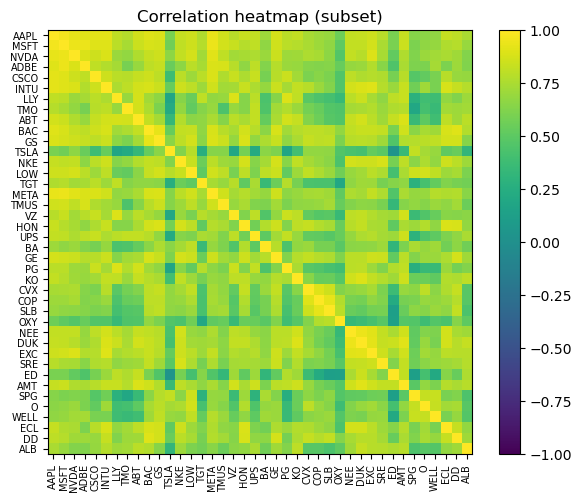

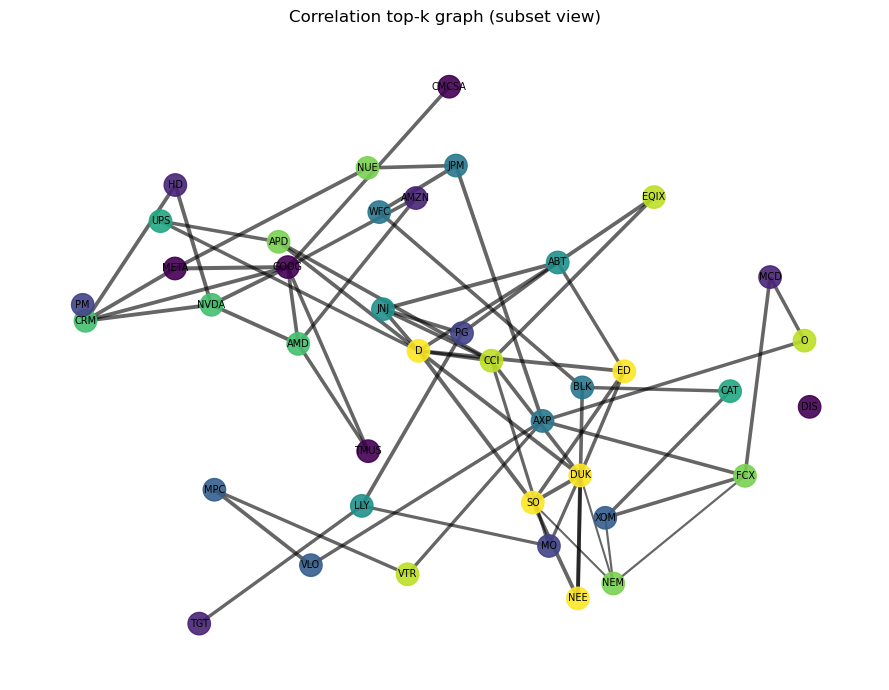

{'n_nodes': 100.0, 'n_edges': 460.0, 'density': 0.09292929292929293, 'n_components': 1.0, 'largest_component_frac': 1.0, 'mean_degree': 9.2, 'p95_degree': 16.099999999999994, 'avg_clustering': 0.41686265057835925}


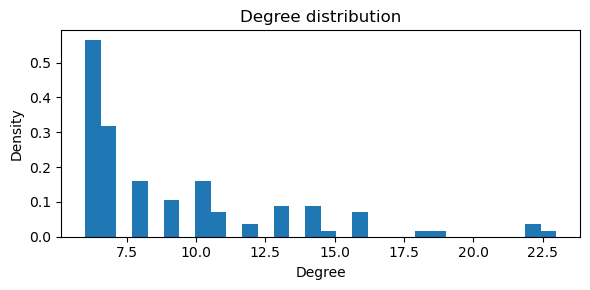

/Users/parinpatel/miniconda3/envs/stocks-gnn/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/parinpatel/miniconda3/envs/stocks-gnn/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [5]:
from src.data.graph_utils import *

snap_i=len(arrays.dates)//2
returns_window=arrays.price[snap_i, :, -CORR_W:, 0]   # [S, CORR_W]

plot_corr_heatmap(returns_window, tickers=arrays.tickers, max_nodes=40, seed=0)

edge_index, edge_attr=corr_graph_topk(returns_window, topk=TOPK, use_abs=True, add_self_loops=False)
sectors=[TICKER_TO_SECTOR.get(t, "Unknown") for t in arrays.tickers]
G=build_nx_graph_from_edge_index(edge_index, edge_attr, tickers=arrays.tickers, sectors=sectors)

plot_graph_networkx(G, max_nodes=40, seed=1)
print(graph_summary_stats(G))
plot_degree_distribution(G)

turn=edge_jaccard_over_time(arrays.price[:, :, :, 0], topk=TOPK, corr_w=CORR_W, step=1, max_pairs=200)


## 4) Define the model (Price LSTM + gated fusion + Corr-Weighted GATv2)

In [6]:
import torch

from src.models.encoders import PriceLSTMEncoder, TextProjector
from src.models.fusion import GatedFusion
from src.models.corr_gat import CorrWeightedGAT

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

fusion_dim = 128
dropout = 0.2

price_encoder = PriceLSTMEncoder(in_dim=arrays.price.shape[-1], hidden=fusion_dim, dropout=dropout)
text_proj     = TextProjector(in_dim=arrays.text.shape[-1], out_dim=fusion_dim, dropout=dropout)
fusion        = GatedFusion(dim=fusion_dim, dropout=dropout)

out_dim = 3 if TASK == "classify" else HORIZON

model = CorrWeightedGAT(
    price_encoder=price_encoder,
    text_proj=text_proj,
    fusion=fusion,
    fusion_dim=fusion_dim,
    gat_hidden=128,
    gat_heads=4,
    gat_layers=2,
    edge_attr_dim=2,  # [|corr|, sign]
    dropout=dropout,
    out_dim=out_dim,
).to(device)

print(model)


Device: mps
CorrWeightedGAT(
  (price_encoder): PriceLSTMEncoder(
    (lstm): LSTM(29, 128, batch_first=True)
    (drop): Dropout(p=0.2, inplace=False)
  )
  (text_proj): TextProjector(
    (net): Sequential(
      (0): Linear(in_features=768, out_features=128, bias=True)
      (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.2, inplace=False)
    )
  )
  (fusion): GatedFusion(
    (gate): Sequential(
      (0): Linear(in_features=257, out_features=128, bias=True)
      (1): GELU(approximate='none')
      (2): Dropout(p=0.2, inplace=False)
      (3): Linear(in_features=128, out_features=1, bias=True)
      (4): Sigmoid()
    )
  )
  (pre): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
  )
  (convs): ModuleList(
    (0-1): 2 x GATv2Conv(128, 32, heads=4)
  )
  (head): Sequential(
    (0): Linear(in_features=256, out_fea

## 5) Train (time split + train-only label thresholds)

In [7]:
from src.train.train_node import *

set_seed(42)

res, splits, (lo, hi), te_loader = train_node_model(
    model=model,
    dataset=ds,
    task=TASK,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=1e-4,
    patience=3,
    label_mode="std",
    threshold_k=0.5,
    device=device,
    splits=(tr_idx, va_idx, te_idx),
    print_every=1,
)

print("Done.")
print("Train thresholds (lo, hi):", (lo, hi))
print("History:", {k: (v[0], v[-1]) for k, v in res.history.items()})


Epoch 001 | train_loss=0.003760 | val_loss=0.003050
Epoch 002 | train_loss=0.002309 | val_loss=0.002017
Epoch 003 | train_loss=0.001590 | val_loss=0.001477
Epoch 004 | train_loss=0.001309 | val_loss=0.001278
Epoch 005 | train_loss=0.001196 | val_loss=0.001254
Epoch 006 | train_loss=0.001411 | val_loss=0.001247
Epoch 007 | train_loss=0.001171 | val_loss=0.001233
Epoch 008 | train_loss=0.001131 | val_loss=0.001231
Epoch 009 | train_loss=0.001124 | val_loss=0.001234
Epoch 010 | train_loss=0.001124 | val_loss=0.001237
Early stopping at epoch 10 (patience=3)
Done.
Train thresholds (lo, hi): (None, None)
History: {'train_loss': (0.0037597190292382784, 0.001123592543246394), 'val_loss': (0.003050148797531923, 0.001236653789722671)}


## 6) Quick evaluation on the test split

MSE: 0.0008932834607549012


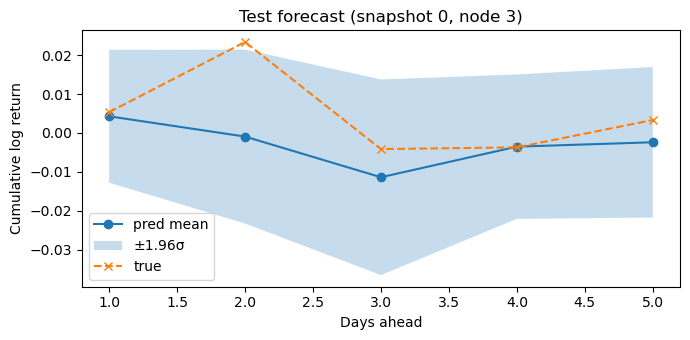

{'pred_mean': array([ 0.00428282, -0.00091671, -0.01136465, -0.00350904, -0.00238111],
      dtype=float32), 'pred_lo': array([-0.01276122, -0.02324991, -0.0364817 , -0.02204702, -0.02170599],
      dtype=float32), 'pred_hi': array([0.02132685, 0.02141649, 0.01375241, 0.01502893, 0.01694377],
      dtype=float32), 'y_true': array([ 0.00533809,  0.02336452, -0.00413432, -0.00368654,  0.00333964],
      dtype=float32)}


In [10]:
eval_device = "cpu"

model_cpu = model.to(eval_device)
model_cpu.eval()

all_y = []
all_pred = []

with torch.no_grad():
    for batch in te_loader:
        batch = batch.to(eval_device)
        out = model_cpu(batch.price, batch.text, batch.text_mask, batch.edge_index, batch.edge_attr)

        if TASK == "classify":
            pred = out.argmax(dim=-1).cpu().numpy()
            y = batch.y.view(-1).cpu().numpy()
        else:
            # multi-horizon regression: [N, H]
            pred = out.cpu().numpy()
            y = batch.y_reg.cpu().numpy()

        all_pred.append(pred)
        all_y.append(y)

y = np.concatenate(all_y, axis=0)
p = np.concatenate(all_pred, axis=0)

if TASK == "classify":
    from sklearn.metrics import classification_report
    print(classification_report(y, p, digits=3))
else:
    from sklearn.metrics import mean_squared_error
    print("MSE:", mean_squared_error(y, p))


out = plot_curve_uncertainty_from_test_loader(
    model=model,
    loader=te_loader,
    snapshot_i=0,     # choose which test batch to visualize
    stock_i=3,     # node index within that batch
    device=eval_device,
    n_samples=80,
)
print(out)

